In [ ]:
import os

In [ ]:
!git clone "https://github.com/Duho0120/Comento_Computer-Vision.git"

Cloning into 'Comento_Computer-Vision'...
remote: Enumerating objects: 242, done.
remote: Counting objects: 100% (123/123), done.
remote: Compressing objects: 100% (116/116), done.
remote: Total 242 (delta 11), reused 101 (delta 5), pack-reused 119 (from 2)
Receiving objects: 100% (242/242), 44.71 MiB | 49.28 MiB/s, done.
Resolving deltas: 100% (13/13), done.
클론 성공


In [ ]:
# 작업 디렉토리 이동
%cd /content/Comento_Computer-Vision

/content/Comento_Computer-Vision


In [ ]:
print(f'현재 위치: ', {os.getcwd()})
!ls -F

현재 위치:  {'/content/Comento_Computer-Vision'}
README.md  task1/  task2/


In [ ]:
!git branch -a

* master
  remotes/origin/HEAD -> origin/master
  remotes/origin/copilot/add-pixel-image-processing-code
  remotes/origin/feature/task1_advanced-preprocessing-FilteringLogic
  remotes/origin/feature/task1_image-preprocessing-pipeline
  remotes/origin/feature/task1_refactoring-feedback
  remotes/origin/feature/task2_2D-3D-Mapping
  remotes/origin/master


In [ ]:
!git checkout -b feature/task3_AI_Modeling

Switched to a new branch 'feature/task3_AI_Modeling'


In [ ]:
!git branch

* feature/task3_AI_Modeling
  master


In [ ]:
pip install torch torchvision opencv-python matplotlib ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.2 MB/s eta 0:00:00


roboflow의 데이터셋 받아오기.

In [ ]:
!pip install roboflow ultralytics -q
import os
from roboflow import Roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 97.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 133.2 MB/s eta 0:00:00


In [ ]:
# task3 데이터 폴더로 이동
!cd task3

In [ ]:
# 데이터 경로
DATA_DIR = "./task3/data"
os.makedirs(DATA_DIR, exist_ok=True)

In [ ]:
%cd task3

/content/Comento_Computer-Vision/task3


In [ ]:
# Roboflow 데이터 다운로드
rf = Roboflow(api_key="oQ5JOFwA1siriOtOBwqW")
project = rf.workspace("pavithraa-sekar").project("neu-surface-defect-dataset")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to NEU-Surface-Defect-Dataset-1 in yolov8:: 100%|██████████| 3607/3607 [00:00<00:00, 9515.17it/s] 


---

### 학습 진행하기

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# YOLOv8 모델 로드하기
model = YOLO("yolov8s.pt")

model.train(
    data="/content/Comento_Computer-Vision/task3/data/NEU-Surface-Defect-Dataset-1/data.yaml",
    epochs=20,
    imgsz=640,
    augment=True,
    name="neu_defect_results"
)

Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Comento_Computer-Vision/task3/data/NEU-Surface-Defect-Dataset-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=neu_defect_results, nbs=64, nms=False, opset=None, optimize=False

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cdf977608c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     


image 1/1 /content/Comento_Computer-Vision/task3/data/NEU-Surface-Defect-Dataset-1/valid/images/rolled-in_scale_257_jpg.rf.ded394cc35d9fb362babfb2ff3bf0681.jpg: 640x640 3 rolled-in_scales, 7.9ms
Speed: 1.7ms preprocess, 7.9ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/Comento_Computer-Vision/task3/data/NEU-Surface-Defect-Dataset-1/valid/images/pitted_surface_243_jpg.rf.09a1a724036b864cb95dcc68bf36aff8.jpg: 640x640 1 pitted_surface, 7.5ms
Speed: 1.6ms preprocess, 7.5ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/Comento_Computer-Vision/task3/data/NEU-Surface-Defect-Dataset-1/valid/images/patches_256_jpg.rf.af38e70f8af424e511c6120c1c1d8d1c.jpg: 640x640 2 patchess, 8.9ms
Speed: 2.0ms preprocess, 8.9ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


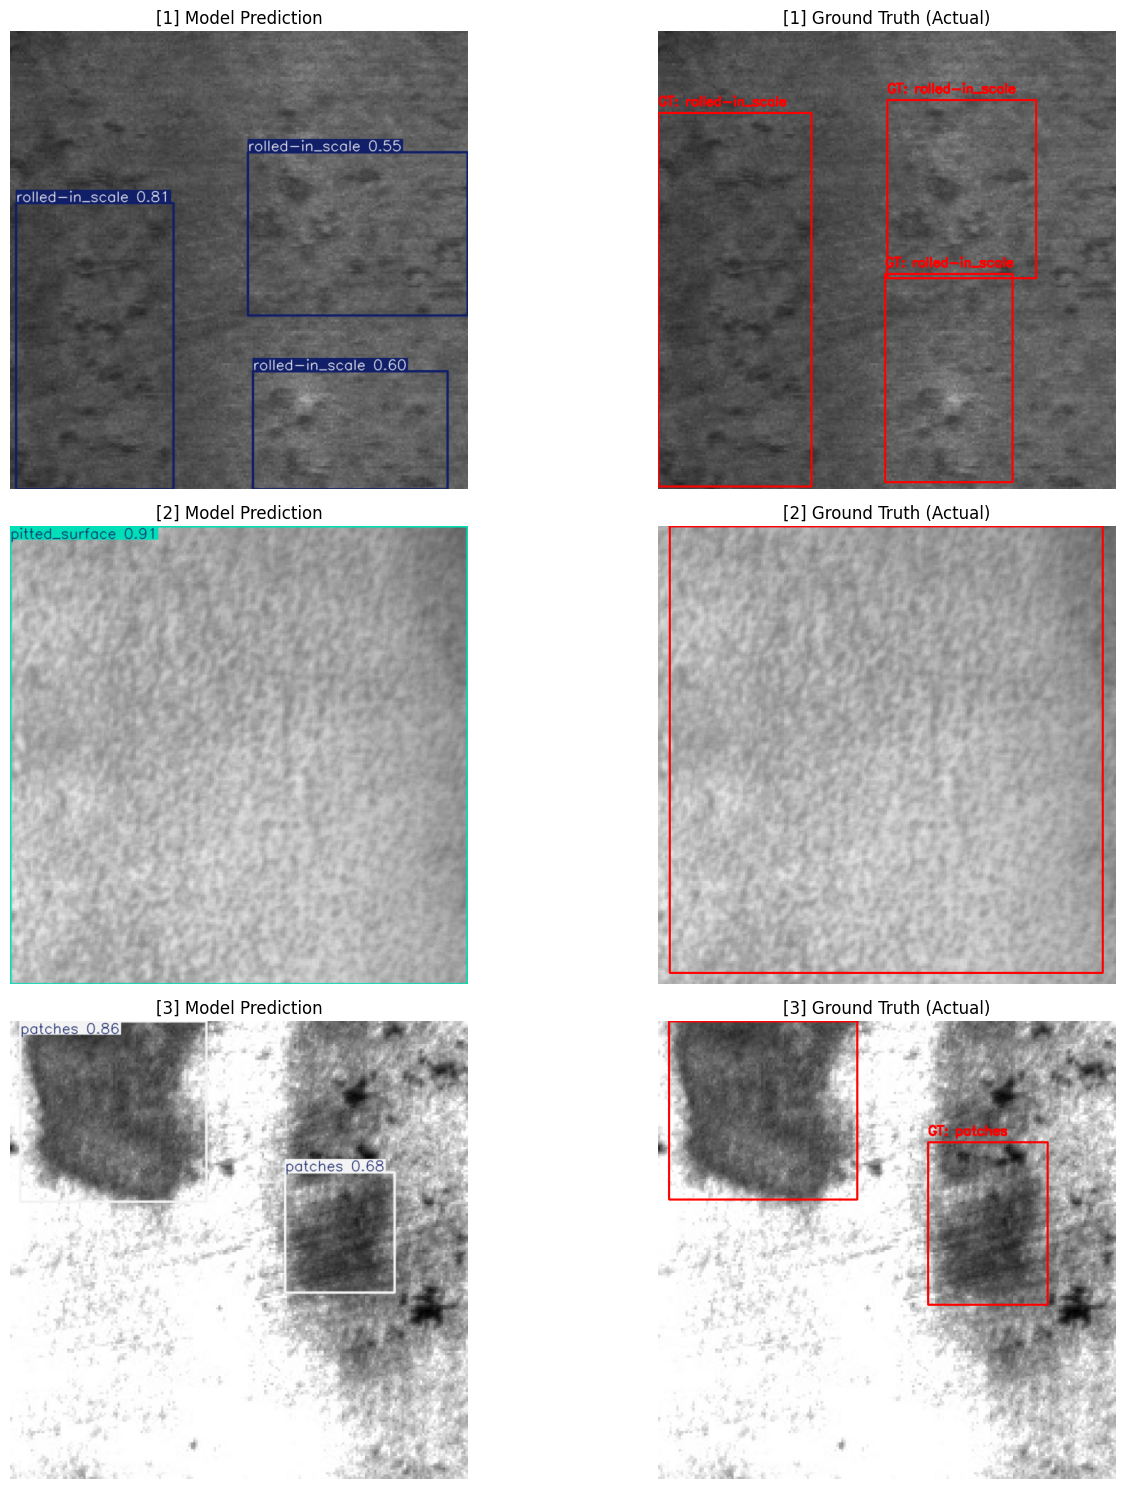

In [ ]:
import cv2
import os
import random
import yaml
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. 모델 로드 및 데이터 설정
model_path = '/content/Comento_Computer-Vision/task3/runs/detect/neu_defect_results/weights/best.pt'
model = YOLO(model_path)

yaml_path = '/content/Comento_Computer-Vision/task3/data/NEU-Surface-Defect-Dataset-1/data.yaml'
with open(yaml_path, 'r') as f:
    data_cfg = yaml.safe_load(f)

# 클래스 이름 매핑 (0: crazing, 1: inclusion 등)
class_names = data_cfg['names']

# 2. 검증셋에서 랜덤 이미지 선택
val_img_dir = data_cfg['val']
val_label_dir = val_img_dir.replace('images', 'labels')
sample_files = random.sample(os.listdir(val_img_dir), 3) # 3개 샘플 확인

# YOLO 형식의 텍스트 라벨을 이미지 위에 그리는 함수
def draw_gt_boxes(image, label_path, names):
    h, w, _ = image.shape
    if not os.path.exists(label_path):
        return image

    with open(label_path, 'r') as f:
        for line in f.readlines():
            cls, x_c, y_c, wb, hb = map(float, line.split())
            # 정규화된 좌표를 픽셀 좌표로 변환
            x1 = int((x_c - wb/2) * w)
            y1 = int((y_c - hb/2) * h)
            x2 = int((x_c + wb/2) * w)
            y2 = int((y_c + hb/2) * h)
            # 정답 박스는 파란색(Blue)으로 표시
            cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(image, f"GT: {names[int(cls)]}", (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
    return image

# 3. 서브플롯 시각화 (Prediction vs Ground Truth)
fig, axes = plt.subplots(len(sample_files), 2, figsize=(15, 5 * len(sample_files)))

for i, file_name in enumerate(sample_files):
    img_path = os.path.join(val_img_dir, file_name)
    lbl_path = os.path.join(val_label_dir, file_name.replace('.jpg', '.txt'))

    # 원본 이미지 로드
    original_img = cv2.imread(img_path)
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

    # [왼쪽] 모델 예측 실행
    results = model(img_path)[0]
    pred_img = results.plot() # YOLO 내장 시각화 (예측값은 보통 빨간색/초록색)
    pred_img = cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB)

    # [오른쪽] 정답 라벨 그리기
    gt_img = original_img.copy()
    gt_img = draw_gt_boxes(gt_img, lbl_path, class_names)

    # 플롯 배치
    axes[i, 0].imshow(pred_img)
    axes[i, 0].set_title(f"[{i+1}] Model Prediction")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(gt_img)
    axes[i, 1].set_title(f"[{i+1}] Ground Truth (Actual)")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
metrics = model.val()

class_names = list(metrics.names.values())
precisions = [metrics.class_result(i)[0] for i in range(len(class_names))]
recalls = [metrics.class_result(i)[1] for i in range(len(class_names))]
maps50 = [metrics.class_result(i)[2] for i in range(len(class_names))]

import pandas as pd

df_metrics = pd.DataFrame({
    'Defect Class': class_names,
    'Precision': precisions,
    'Recall': recalls,
    'mAP@0.5': maps50
})

print("--- 전체 검증셋 평가 결과 ---")
print(f"\n전체 평균 mAP50: {metrics.box.map50:.4f}")
print(f"전체 평균 Precision: {metrics.box.mp:.4f}")
print(f"전체 평균 Recall: {metrics.box.mr:.4f}")

Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1635.8±635.2 MB/s, size: 45.2 KB)
val: Scanning /content/Comento_Computer-Vision/task3/data/NEU-Surface-Defect-Dataset-1/valid/labels.cache... 360 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 360/360 151.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 7.2it/s 3.2s
                   all        360        854       0.72      0.639      0.738      0.384
               crazing         60        162      0.606      0.209      0.456      0.173
             inclusion         71        159      0.834      0.698      0.822      0.438
               patches         73        193      0.857      0.891      0.931      0.584
        pitted_surface         60         87      0.858      0.692      0.815      0.425
       rolled-in_scale         60        132      0.554      

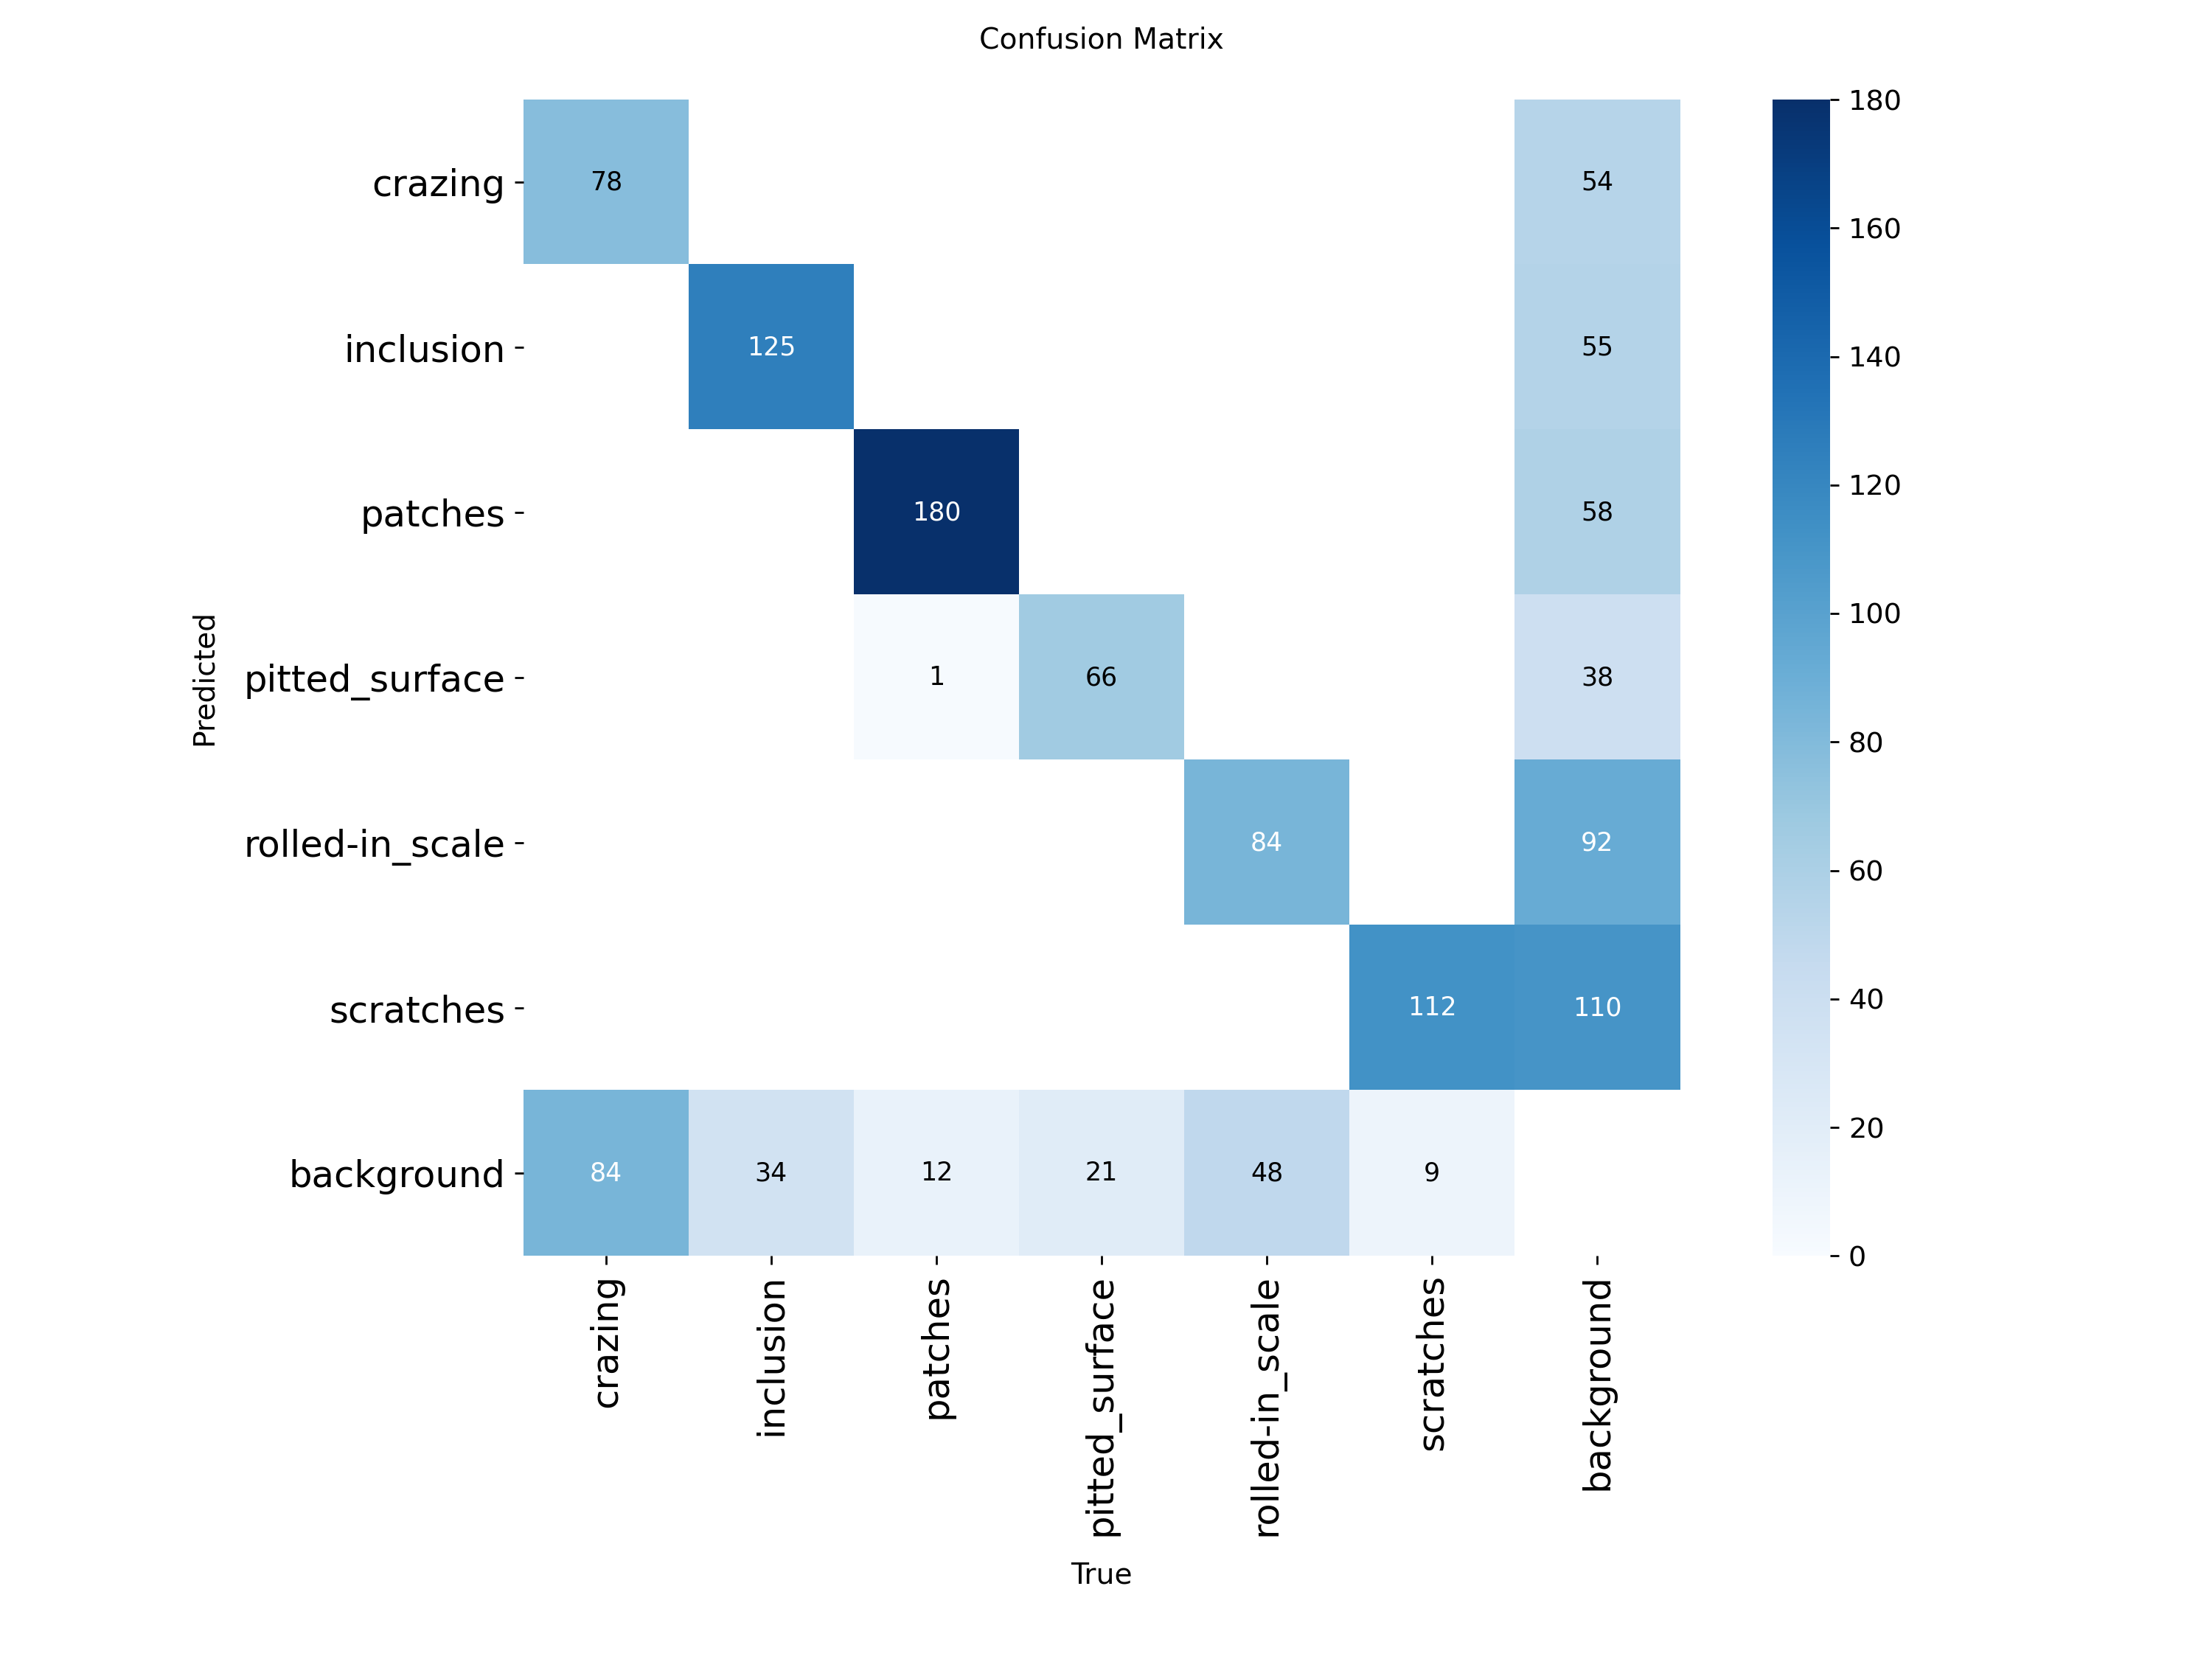

In [ ]:
from IPython.display import Image
import os

# 학습 결과 폴더 내의 Confusion Matrix 이미지 출력
results_dir = '/content/Comento_Computer-Vision/task3/runs/detect/neu_defect_results'
Image(filename=os.path.join(results_dir, 'confusion_matrix.png'))

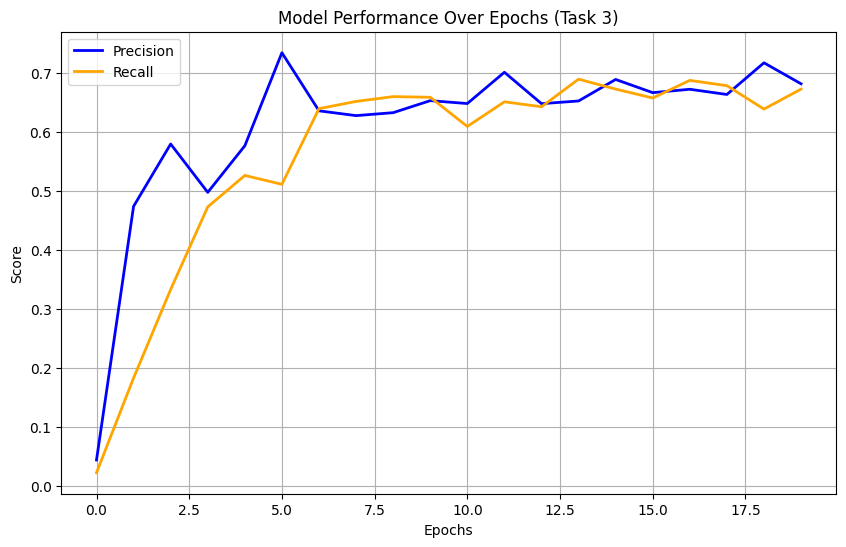

In [ ]:
results_path = "/content/Comento_Computer-Vision/task3/runs/detect/neu_defect_results/results.csv"
results = pd.read_csv(results_path)

plt.figure(figsize=(10, 6))

# YOLOv8 결과 파일의 컬럼명을 확인하여 매핑
plt.plot(results['metrics/precision(B)'], label="Precision", color='blue', linewidth=2)
plt.plot(results['metrics/recall(B)'], label="Recall", color='orange', linewidth=2)

plt.xlabel("Epochs")
plt.ylabel("Score")
plt.legend()
plt.title("Model Performance Over Epochs (Task 3)")
plt.grid(True)

plt.show()

---

### 지금까지 진행한 내용 깃허브에 반영

In [ ]:
%ls

data/  runs/  src/  yolo26n.pt  yolov8s.pt


In [ ]:
%cd /content/Comento_Computer-Vision

/content/Comento_Computer-Vision


In [ ]:
!git status

On branch feature/task3_AI_Modeling
Untracked files:
  (use "git add <file>..." to include in what will be committed)
	task3/

nothing added to commit but untracked files present (use "git add" to track)


In [ ]:
!git branch

* feature/task3_AI_Modeling
  master


In [ ]:
!git add .

In [ ]:
!git status

On branch feature/task3_AI_Modeling
Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   task3/data/NEU-Surface-Defect-Dataset-1/README.dataset.txt
	new file:   task3/data/NEU-Surface-Defect-Dataset-1/README.roboflow.txt
	new file:   task3/data/NEU-Surface-Defect-Dataset-1/data.yaml
	new file:   task3/data/NEU-Surface-Defect-Dataset-1/train/images/crazing_100_jpg.rf.80e4fd6411171e6223d9310c3925f271.jpg
	new file:   task3/data/NEU-Surface-Defect-Dataset-1/train/images/crazing_101_jpg.rf.352873ff6b4e1212ab8e26c63311bbc6.jpg
	new file:   task3/data/NEU-Surface-Defect-Dataset-1/train/images/crazing_102_jpg.rf.0776af296c182c2ab00d0098eb99548f.jpg
	new file:   task3/data/NEU-Surface-Defect-Dataset-1/train/images/crazing_103_jpg.rf.e872d71ed409f424e674437e8ca83b23.jpg
	new file:   task3/data/NEU-Surface-Defect-Dataset-1/train/images/crazing_104_jpg.rf.61b6a2e42f87ef18d010950d9135f443.jpg
	new file:   task3/data/NEU-Surface-Defect-Dataset-1/train/images/cra

In [ ]:
!git config --global user.email "dlenghdooho@gmail.com"
!git config --global user.name "Duho0120"

In [ ]:
!git commit -m "Task3 - NEU-Dataset Using YOLOv8s and Training Model and Visualization"

[feature/task3_AI_Modeling a4c2a2b] Task3 - NEU-Dataset Using YOLOv8s and Training Model and Visualization
 3653 files changed, 4367 insertions(+)
 create mode 100644 task3/data/NEU-Surface-Defect-Dataset-1/README.dataset.txt
 create mode 100644 task3/data/NEU-Surface-Defect-Dataset-1/README.roboflow.txt
 create mode 100644 task3/data/NEU-Surface-Defect-Dataset-1/data.yaml
 create mode 100644 task3/data/NEU-Surface-Defect-Dataset-1/train/images/crazing_100_jpg.rf.80e4fd6411171e6223d9310c3925f271.jpg
 create mode 100644 task3/data/NEU-Surface-Defect-Dataset-1/train/images/crazing_101_jpg.rf.352873ff6b4e1212ab8e26c63311bbc6.jpg
 create mode 100644 task3/data/NEU-Surface-Defect-Dataset-1/train/images/crazing_102_jpg.rf.0776af296c182c2ab00d0098eb99548f.jpg
 create mode 100644 task3/data/NEU-Surface-Defect-Dataset-1/train/images/crazing_103_jpg.rf.e872d71ed409f424e674437e8ca83b23.jpg
 create mode 100644 task3/data/NEU-Surface-Defect-Dataset-1/train/images/crazing_104_jpg.rf.61b6a2e42f87ef18

In [ ]:
with open(".gitignore", 'w') as f:
    f.write("task3/data/\n") # 데이터가 들어간 폴더만 제외

In [ ]:
# 이미 커밋을 진행하였기 때문에 data폴더를 추적 목록에서만 제거 (캐시 삭제)
!git rm -r --cached task3/data/

rm 'task3/data/NEU-Surface-Defect-Dataset-1/README.dataset.txt'
rm 'task3/data/NEU-Surface-Defect-Dataset-1/README.roboflow.txt'
rm 'task3/data/NEU-Surface-Defect-Dataset-1/data.yaml'
rm 'task3/data/NEU-Surface-Defect-Dataset-1/train/images/crazing_100_jpg.rf.80e4fd6411171e6223d9310c3925f271.jpg'
rm 'task3/data/NEU-Surface-Defect-Dataset-1/train/images/crazing_101_jpg.rf.352873ff6b4e1212ab8e26c63311bbc6.jpg'
rm 'task3/data/NEU-Surface-Defect-Dataset-1/train/images/crazing_102_jpg.rf.0776af296c182c2ab00d0098eb99548f.jpg'
rm 'task3/data/NEU-Surface-Defect-Dataset-1/train/images/crazing_103_jpg.rf.e872d71ed409f424e674437e8ca83b23.jpg'
rm 'task3/data/NEU-Surface-Defect-Dataset-1/train/images/crazing_104_jpg.rf.61b6a2e42f87ef18d010950d9135f443.jpg'
rm 'task3/data/NEU-Surface-Defect-Dataset-1/train/images/crazing_105_jpg.rf.ee3a8fe1a7240aa4fb3aa06ce4d28394.jpg'
rm 'task3/data/NEU-Surface-Defect-Dataset-1/train/images/crazing_106_jpg.rf.08bb0a4567bf66c56835f05505d11230.jpg'
rm 'task3/data/NEU

In [ ]:
!git add .

In [ ]:
!git commit -m "Task3 - Making gitignore and Removing data folder from tracking"

[feature/task3_AI_Modeling 88d2618] Task3 - Making gitignore and Removing data folder from tracking
 3604 files changed, 1 insertion(+), 4238 deletions(-)
 create mode 100644 .gitignore
 delete mode 100644 task3/data/NEU-Surface-Defect-Dataset-1/README.dataset.txt
 delete mode 100644 task3/data/NEU-Surface-Defect-Dataset-1/README.roboflow.txt
 delete mode 100644 task3/data/NEU-Surface-Defect-Dataset-1/data.yaml
 delete mode 100644 task3/data/NEU-Surface-Defect-Dataset-1/train/images/crazing_100_jpg.rf.80e4fd6411171e6223d9310c3925f271.jpg
 delete mode 100644 task3/data/NEU-Surface-Defect-Dataset-1/train/images/crazing_101_jpg.rf.352873ff6b4e1212ab8e26c63311bbc6.jpg
 delete mode 100644 task3/data/NEU-Surface-Defect-Dataset-1/train/images/crazing_102_jpg.rf.0776af296c182c2ab00d0098eb99548f.jpg
 delete mode 100644 task3/data/NEU-Surface-Defect-Dataset-1/train/images/crazing_103_jpg.rf.e872d71ed409f424e674437e8ca83b23.jpg
 delete mode 100644 task3/data/NEU-Surface-Defect-Dataset-1/train/ima

In [ ]:
!git push origin feature/task3_AI_Modeling

fatal: could not read Username for 'https://github.com': No such device or address


In [ ]:
!git push origin feature/task3_AI_Modeling

Enumerating objects: 3632, done.
Counting objects: 100% (3632/3632), done.
Delta compression using up to 12 threads
Compressing objects: 100% (3176/3176), done.
Writing objects: 100% (3631/3631), 141.41 MiB | 15.98 MiB/s, done.
Total 3631 (delta 5), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (5/5), done.
remote: 
remote: Create a pull request for 'feature/task3_AI_Modeling' on GitHub by visiting:
remote:      https://github.com/Duho0120/Comento_Computer-Vision/pull/new/feature/task3_AI_Modeling
remote: 
To https://github.com/Duho0120/Comento_Computer-Vision.git
 * [new branch]      feature/task3_AI_Modeling -> feature/task3_AI_Modeling


In [ ]:
!git checkout master

Switched to branch 'master'
Your branch is up to date with 'origin/master'.


In [ ]:
!git merge feature/task3_AI_Modeling

Updating a086b0f..88d2618
Fast-forward
 .gitignore                                         |   1 +
 .../runs/detect/neu_defect_results/BoxF1_curve.png | Bin 0 -> 304120 bytes
 .../runs/detect/neu_defect_results/BoxPR_curve.png | Bin 0 -> 216333 bytes
 .../runs/detect/neu_defect_results/BoxP_curve.png  | Bin 0 -> 273308 bytes
 .../runs/detect/neu_defect_results/BoxR_curve.png  | Bin 0 -> 261167 bytes
 task3/runs/detect/neu_defect_results/args.yaml     | 108 +++++++++++++++++++++
 .../detect/neu_defect_results/confusion_matrix.png | Bin 0 -> 189880 bytes
 .../confusion_matrix_normalized.png                | Bin 0 -> 201708 bytes
 task3/runs/detect/neu_defect_results/labels.jpg    | Bin 0 -> 207621 bytes
 task3/runs/detect/neu_defect_results/results.csv   |  21 ++++
 task3/runs/detect/neu_defect_results/results.png   | Bin 0 -> 240553 bytes
 .../detect/neu_defect_results/train_batch0.jpg     | Bin 0 -> 527187 bytes
 .../detect/neu_defect_results/train_batch1.jpg     | Bin 0 -> 467150 byte

In [ ]:
!git push origin master

Total 0 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/Duho0120/Comento_Computer-Vision.git
   a086b0f..88d2618  master -> master
